# Phase 5 — Writeup Figures

Generates the figures embedded in README.md. Source of truth is `data/processed/snapshot_ledger.yaml`.

To refresh figures after a new fresh fetch, run from the repo root:
```bash
uv run python scripts/compute_arb.py --fresh
uv run jupyter nbconvert --to notebook --execute notebooks/04_writeup_figures.ipynb
```

In [ ]:
import sys
sys.path.insert(0, "../src")

import yaml
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.family"] = "monospace"

with open("../data/processed/snapshot_ledger.yaml") as f:
    ledger = yaml.safe_load(f)

ledger_df = pd.DataFrame(ledger)
ledger_df["timestamp_utc"] = pd.to_datetime(ledger_df["timestamp_utc"], format="mixed")
ledger_df = ledger_df.sort_values("timestamp_utc").reset_index(drop=True)
ledger_df

,timestamp_utc,source,okc_kalshi_mid,okc_polymarket_yes_mid,okc_discrepancy_cents,nyk_polymarket_yes_status,notes,cle_polymarket_status
0,2026-05-25 22:09:56+00:00,phase_3_snapshot,0.475,0.485,1.0,active,Initial Phase 3 snapshot. All three markets ha...,NaN
1,2026-05-26 08:00:00+00:00,phase_4_fresh_first,0.480,0.485,0.5,active_then_404,OKC narrowed by half. NYK YES still active at ...,NaN
2,2026-05-26 16:00:00+00:00,phase_4_fresh_second,0.485,0.485,0.0,404,OKC fully converged. NYK YES 404 — Polymarket ...,NaN
3,2026-05-26 19:32:24+00:00,phase_5_fresh,0.455,0.455,0.0,404,Both venues now price OKC at 0.455 (down 3 cen...,404


## Hero figure — OKC cross-venue discrepancy decay over time

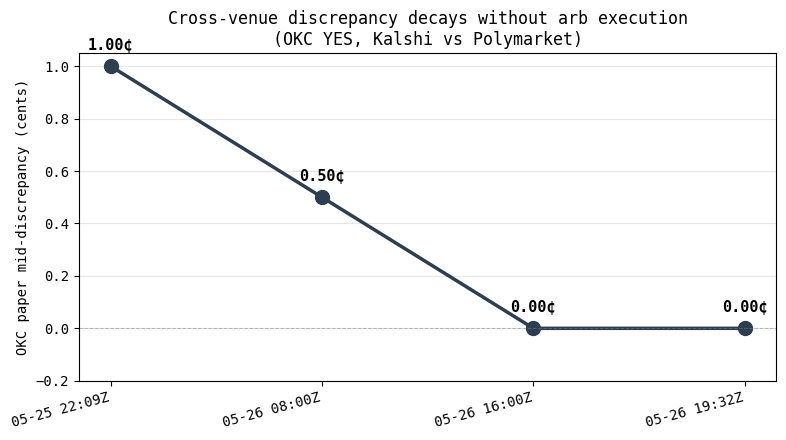

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x = range(len(ledger_df))
ax.plot(x, ledger_df["okc_discrepancy_cents"],
        marker="o", markersize=10, linewidth=2.5, color="#2c3e50")

for i, row in ledger_df.iterrows():
    val = row["okc_discrepancy_cents"]
    if pd.notna(val):
        ax.annotate(f"{val:.2f}¢", (i, val),
                    textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=11, fontweight="bold")

labels = [t.strftime("%m-%d %H:%MZ") for t in ledger_df["timestamp_utc"]]
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15, ha="right")

ax.set_ylabel("OKC paper mid-discrepancy (cents)")
ax.set_title("Cross-venue discrepancy decays without arb execution\n(OKC YES, Kalshi vs Polymarket)")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_ylim(bottom=min(ledger_df["okc_discrepancy_cents"].min() - 0.2, -0.2))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/fig_okc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## Supporting figure — Executable profit after fees

(Reuses Phase 4's figure but with cleaner styling for the README.)

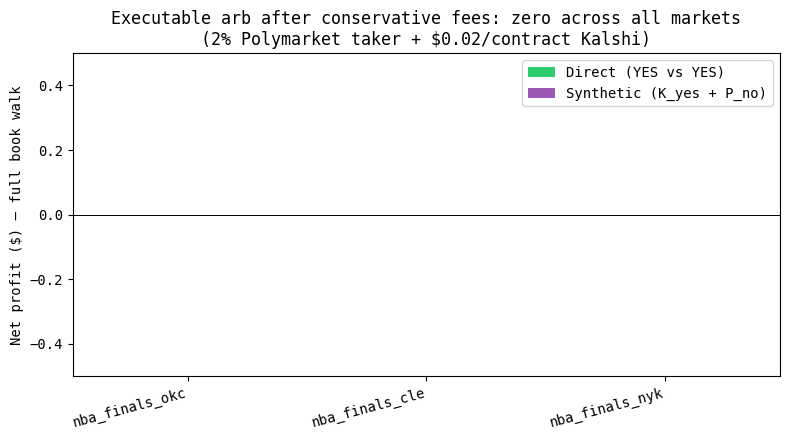

In [3]:
arb_df = pd.read_csv("../data/processed/arb_results_fresh.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(arb_df))
width = 0.35
ax.bar([i - width/2 for i in x], arb_df["exec_direct_net_profit"],
       width=width, label="Direct (YES vs YES)", color="#2ecc71")
ax.bar([i + width/2 for i in x], arb_df["exec_synthetic_net_profit"],
       width=width, label="Synthetic (K_yes + P_no)", color="#9b59b6")
ax.set_xticks(list(x))
ax.set_xticklabels(arb_df["market_id"], rotation=15, ha="right")
ax.set_ylabel("Net profit ($) — full book walk")
ax.set_title("Executable arb after conservative fees: zero across all markets\n(2% Polymarket taker + $0.02/contract Kalshi)")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylim(-0.5, 0.5)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_executable_zero.png", dpi=150, bbox_inches="tight")
plt.show()